# Notebook limpio de manin, aquí probaremos nuevas estrategias con orderflow

In [1]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data


## Importamos los datos 

In [2]:
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol=["QQQ", "TLT", "VXX", "BNDX"],
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-02-02",
    
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()

df = preprocess_data(df_raw, "qqq")

df.head()


c:\Users\jorge\OneDrive\Escritorio\TRADING_ALG\src\data_cleaner.py:242: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["return"] = df["close"].pct_change()


,datetime,open_bndx,open_qqq,open_tlt,open_vxx,high_bndx,high_qqq,high_tlt,high_vxx,low_bndx,...,log_return_lag5,vol_rolling,rsi,macd,macd_signal,ema_9,ema_21,ema_50,ema_100,ema_200
0,2022-01-03 14:25:00+00:00,55.06,399.38,146.55,18.2100,55.060,399.41,146.600,18.30,55.06,...,-0.000275,0.000512,21.777778,-0.000707,-0.000518,399.110000,399.110000,399.110000,399.110000,399.110000
1,2022-01-03 14:30:00+00:00,55.03,399.05,146.41,18.2700,55.060,400.68,146.500,18.29,55.01,...,0.000601,0.000921,50.991501,-0.000474,-0.000509,399.372000,399.229091,399.161373,399.135941,399.123035
2,2022-01-03 14:35:00+00:00,55.02,400.44,146.36,18.1200,55.035,401.53,146.595,18.16,55.01,...,-0.000025,0.000983,60.246913,-0.000158,-0.000439,399.709600,399.395537,399.235829,399.174041,399.142308
3,2022-01-03 14:40:00+00:00,55.03,401.07,146.57,18.0701,55.040,401.26,146.800,18.15,55.03,...,0.000326,0.001024,57.547170,-0.000008,-0.000353,399.879680,399.501397,399.287757,399.201486,399.156414
4,2022-01-03 14:45:00+00:00,55.03,400.57,146.53,18.1100,55.050,400.75,146.940,18.56,55.03,...,-0.000050,0.001669,36.489076,-0.000359,-0.000354,399.547244,399.384679,399.245786,399.182001,399.147072


º# Definimos el target
*df["ret_fwd"] = df["close"].shift(-H) / df["close"] - 1* -> Crea una nueva columna ret_fwd y calcula el retorno porcentual (ejemplo: si hoy close es 100, en H velas close = 101 -> 1%)

*df.loc[df["ret_fwd"] >  thr, "y"] = 1* -> Crea la etiqueta binaria Y.  y = 1 si el retorno futuro es positivo y 0 si es negativo

# Resumen: 
Calculamos el retorno futuro a H velas (ret_fwd).

Solo etiquetamos como sube (1) si el movimiento supera +thr y como baja (0) si baja más de -thr.

Todo lo que sea “ruido” (entre -thr y +thr) lo descartamos para entrenar con ejemplos más claros.

In [6]:

H = 24
thr_min = 0.0005   # mínimo (5 bps)
k = 1.0            # multiplicador de vol (prueba 0.5, 1.0, 1.5)
vol_win = 78       # ventana vol (5m RTH ~ 1 día). si 24h usa 288

df = df.copy()

# vol ex-ante (solo pasado)
df["logret"] = np.log(df["close"]).diff()
df["vol"] = df["logret"].rolling(vol_win).std().shift(1)

# umbral dinámico
df["thr_dyn"] = np.maximum(thr_min, k * df["vol"] * np.sqrt(H))
# retorno futuro y etiqueta
df["ret_fwd"] = df["close"].shift(-H) / df["close"] - 1
df["y"] = np.where(df["ret_fwd"] >  df["thr_dyn"], 1,
           np.where(df["ret_fwd"] < -df["thr_dyn"], 0, np.nan))

df = df.dropna(subset=["y"]).reset_index(drop=True)
df["y"] = df["y"].astype(int)


In [19]:
import numpy as np
import pandas as pd

def make_features(df, max_other_closes=8):
    d = df.copy()

    # =====================
    # 0) returns base
    # =====================
    d["logret1"] = np.log(d["close"]).diff()
    d["ret1"]    = d["close"].pct_change()

    # =====================
    # 1) momentum multi-horizonte
    # =====================
    for l in [2, 3, 6, 12, 24, 48, 96]:
        d[f"logret_{l}"] = np.log(d["close"] / d["close"].shift(l))

    # =====================
    # 2) vol multi-ventana (sobre logret1)
    # =====================
    for w in [5, 10, 20, 78, 156]:
        d[f"sigma_{w}"] = d["logret1"].rolling(w).std()

    # z-scores rápidos
    d["zret_20"] = d["logret1"] / (d["sigma_20"] + 1e-8)
    d["zret_78"] = d["logret1"] / (d["sigma_78"] + 1e-8)

    # =====================
    # 3) trend: MA/EMA + distancias
    # =====================
    for w in [20, 78]:
        ma = d["close"].rolling(w).mean()
        d[f"dist_ma_{w}"] = d["close"] / (ma + 1e-12) - 1

        ema = d["close"].ewm(span=w, adjust=False).mean()
        d[f"dist_ema_{w}"] = d["close"] / (ema + 1e-12) - 1

    # =====================
    # 4) posición en rango (breakout / mean reversion)
    # =====================
    for w in [20, 78]:
        lo = d["close"].rolling(w).min()
        hi = d["close"].rolling(w).max()
        d[f"pos_{w}"] = (d["close"] - lo) / (hi - lo + 1e-8)  # 0..1

    # =====================
    # 5) RSI + MACD hist pct
    # =====================
    dd = d["close"].diff()
    up = dd.clip(lower=0)
    dn = (-dd).clip(lower=0)
    rs = up.rolling(14).mean() / (dn.rolling(14).mean() + 1e-12)
    d["rsi"] = 100 - 100/(1+rs)

    ema12 = d["close"].ewm(span=12, adjust=False).mean()
    ema26 = d["close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    d["macd_hist_pct"] = (macd - sig) / (d["close"] + 1e-12)

    # =====================
    # 6) time-of-day / day-of-week (si hay datetime)
    # =====================
    ts = None
    if isinstance(d.index, pd.DatetimeIndex):
        ts = d.index
    else:
        # intenta encontrar una columna temporal típica
        for c in ["datetime", "date", "timestamp", "time"]:
            if c in d.columns:
                try:
                    ts = pd.to_datetime(d[c])
                    break
                except Exception:
                    pass

    if ts is not None:
        minutes = ts.hour * 60 + ts.minute
        d["tod_sin"] = np.sin(2*np.pi*minutes/1440)
        d["tod_cos"] = np.cos(2*np.pi*minutes/1440)

        dow = ts.dayofweek
        d["dow_sin"] = np.sin(2*np.pi*dow/7)
        d["dow_cos"] = np.cos(2*np.pi*dow/7)
    else:
        d["tod_sin"] = np.nan
        d["tod_cos"] = np.nan
        d["dow_sin"] = np.nan
        d["dow_cos"] = np.nan

    # =====================
    # 7) volumen (si existe)
    # =====================
    if "volume" in d.columns:
        v = d["volume"].astype(float)
        d["logvol"] = np.log(v + 1.0)
        d["vol_z20"] = (d["logvol"] - d["logvol"].rolling(20).mean()) / (d["logvol"].rolling(20).std() + 1e-8)
    else:
        d["logvol"] = np.nan
        d["vol_z20"] = np.nan

    # =====================
    # 8) cross-asset (si tienes close_* o *_close)
    # =====================
    other = []
    for c in d.columns:
        cl = c.lower()
        if c == "close":
            continue
        if cl.startswith("close_") or cl.endswith("_close"):
            other.append(c)

    other = other[:max_other_closes]
    for c in other:
        name = c.lower().replace("close", "").strip("_")
        d[f"{name}_logret1"] = np.log(d[c]).diff()
        d[f"{name}_sigma20"] = d[f"{name}_logret1"].rolling(20).std()
        # relativo al activo principal (a veces ayuda)
        d[f"rel_{name}_logret1"] = d["logret1"] - d[f"{name}_logret1"]

    # =====================
    # lista final de features
    # =====================
    feat_cols = (
        ["ret1","logret1"]
        + [f"logret_{l}" for l in [2,3,6,12,24,48,96]]
        + [f"sigma_{w}" for w in [5,10,20,78,156]]
        + ["zret_20","zret_78"]
        + [f"dist_ma_{w}" for w in [20,78]]
        + [f"dist_ema_{w}" for w in [20,78]]
        + [f"pos_{w}" for w in [20,78]]
        + ["rsi","macd_hist_pct"]
        + ["tod_sin","tod_cos","dow_sin","dow_cos"]
        + ["logvol","vol_z20"]
    )

    # añade cross-asset cols a feat_cols
    for c in other:
        name = c.lower().replace("close", "").strip("_")
        feat_cols += [f"{name}_logret1", f"{name}_sigma20", f"rel_{name}_logret1"]

    # limpia
    d = d.dropna(subset=feat_cols + ["y"]).reset_index(drop=True)
    return d, feat_cols

{'rows_used': 18930, 'seq_rows': 18803, 'L': 128, 'hidden': 64, 'dropout_type': 'locked', 'p_in': 0.05, 'p_h': 0.05, 'use_pos_weight': False, 'weight_decay': 0.0001, 'y_train_mean': 0.5110925391277922, 'y_val_mean': 0.45886524822695035, 'y_test_mean': 0.554058844381425, 'AUC_val': 0.5298271485898218, 'AUC_test': 0.5820476398267975, 'tbest': 0.625, 'pred_pos_rate': 0.31478199220134706, 'bal_val': 0.5592658727345283, 'bal_test': 0.5710149858563542}
Confusion matrix (test):
 [[961 297]
 [972 591]]


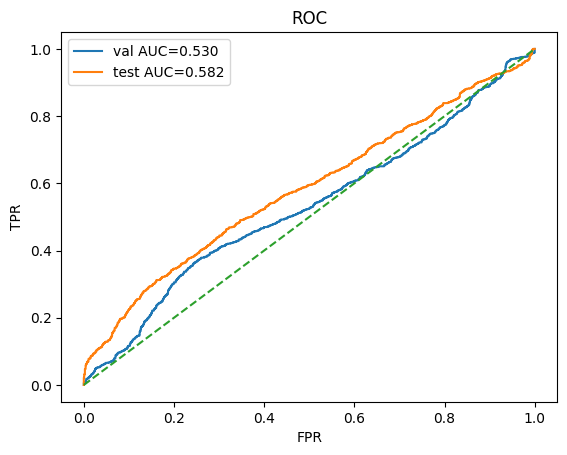

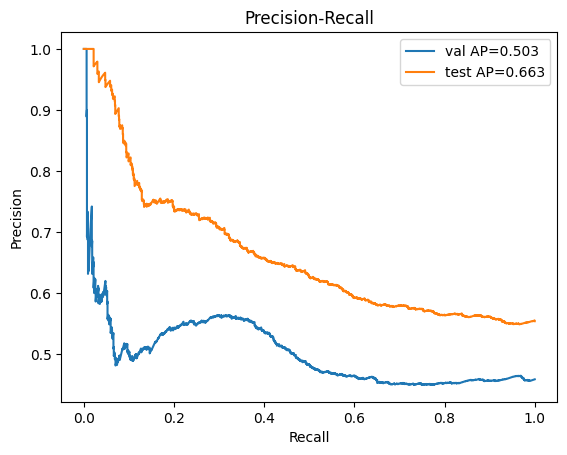

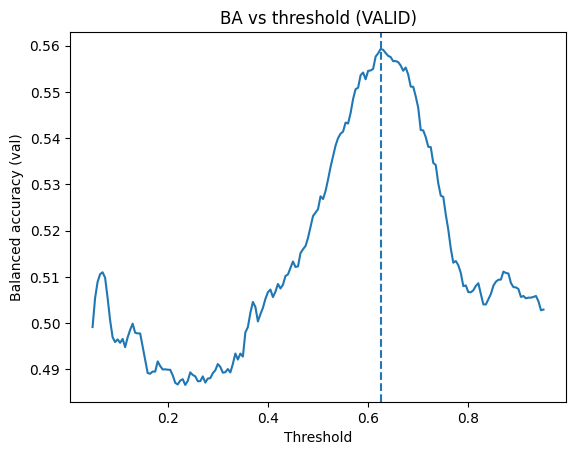

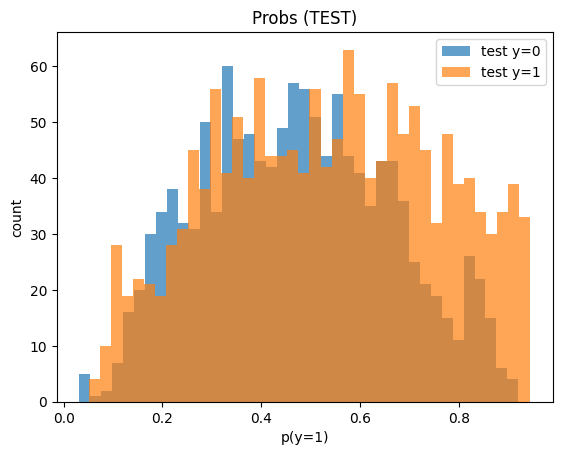

AUC_val: 0.5298271485898218 | AUC_test: 0.5820476398267975 | AP_val: 0.5028085265638169 | AP_test: 0.6631597227897638


{'rows_used': 18930,
 'seq_rows': 18803,
 'L': 128,
 'hidden': 64,
 'dropout_type': 'locked',
 'p_in': 0.05,
 'p_h': 0.05,
 'use_pos_weight': False,
 'weight_decay': 0.0001,
 'y_train_mean': 0.5110925391277922,
 'y_val_mean': 0.45886524822695035,
 'y_test_mean': 0.554058844381425,
 'AUC_val': 0.5298271485898218,
 'AUC_test': 0.5820476398267975,
 'tbest': 0.625,
 'pred_pos_rate': 0.31478199220134706,
 'bal_val': 0.5592658727345283,
 'bal_test': 0.5710149858563542}

In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# =========================================================
# ASUME que ya tienes:
# - df con target df["y"] (0/1) definido
# - make_features(df) -> (d, feat_cols) definido (el nuevo con +features)
# =========================================================

def build_sequences(d, feat_cols, L=128):
    X = d[feat_cols].to_numpy(np.float32)
    y = d["y"].to_numpy(np.int64)

    Xs, ys = [], []
    for t in range(L-1, len(d)):
        Xs.append(X[t-L+1:t+1])   # pasado hasta t (incluye t)
        ys.append(y[t])
    return np.stack(Xs), np.array(ys, dtype=np.int64)

class LockedDropout(nn.Module):
    """Mismo mask en todos los timesteps (variational/locked dropout)."""
    def __init__(self, p=0.05):
        super().__init__()
        self.p = float(p)

    def forward(self, x):
        if (not self.training) or self.p <= 0.0:
            return x
        if x.dim() == 3:  # (B,L,F)
            B, L, F = x.shape
            mask = x.new_empty(B, 1, F).bernoulli_(1 - self.p).div_(1 - self.p)
            return x * mask
        if x.dim() == 2:  # (B,F)
            B, F = x.shape
            mask = x.new_empty(B, F).bernoulli_(1 - self.p).div_(1 - self.p)
            return x * mask
        return nn.functional.dropout(x, p=self.p, training=True)

def make_dropout(dropout_type="locked", p=0.05):
    if dropout_type in [None, "none"] or p <= 0:
        return nn.Identity()
    if dropout_type == "locked":
        return LockedDropout(p=p)
    if dropout_type == "standard":
        return nn.Dropout(p=p)
    raise ValueError("dropout_type: 'locked' | 'standard' | 'none'")

class TinyLSTM(nn.Module):
    def __init__(self, nfeat, hidden=64, dropout_type="locked", p_in=0.05, p_h=0.05):
        super().__init__()
        self.drop_in = make_dropout(dropout_type, p_in)
        self.lstm = nn.LSTM(input_size=nfeat, hidden_size=hidden, num_layers=1, batch_first=True)
        self.drop_h = make_dropout(dropout_type, p_h)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.drop_in(x)
        out, (hn, cn) = self.lstm(x)
        h_last = hn[-1]
        h_last = self.drop_h(h_last)
        return self.head(h_last)

def _best_threshold_balacc(p, y, tie_break=True):
    ths = np.linspace(0.05, 0.95, 181)
    ba  = np.array([balanced_accuracy_score(y, (p > t).astype(int)) for t in ths])

    if tie_break:
        max_ba = ba.max()
        idxs = np.where(np.isclose(ba, max_ba, atol=1e-4))[0]
        rates = np.array([(p > ths[i]).mean() for i in idxs])
        i_best = idxs[np.argmin(np.abs(rates - y.mean()))]
        tbest = float(ths[i_best])
    else:
        tbest = float(ths[int(ba.argmax())])

    return float(ba.max()), tbest, ths, ba

def run_lstm(
    df,
    L=128,
    hidden=64,
    epochs=20,
    lr=1e-3,
    batch_size=256,
    seed=0,
    dropout_type="locked",
    p_in=0.05,
    p_h=0.05,
    use_pos_weight=False,
    weight_decay=1e-4,
    clip_grad=1.0,
    tie_break=True,
    early_stop=True,
    patience=3
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    d, feat_cols = make_features(df)
    Xs, ys = build_sequences(d, feat_cols, L=L)

    # split temporal 70/15/15
    n = len(ys)
    i1 = int(0.70*n)
    i2 = int(0.85*n)
    Xtr, ytr = Xs[:i1], ys[:i1]
    Xva, yva = Xs[i1:i2], ys[i1:i2]
    Xte, yte = Xs[i2:], ys[i2:]

    # normalizar con train (por feature)
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-8
    Xtr = (Xtr - mu) / sd
    Xva = (Xva - mu) / sd
    Xte = (Xte - mu) / sd

    Xtr_t = torch.tensor(Xtr, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).view(-1, 1)
    Xva_t = torch.tensor(Xva, device=device)
    Xte_t = torch.tensor(Xte, device=device)

    # loss
    if use_pos_weight:
        pos = float(ytr_t.sum().item())
        neg = float(len(ytr_t) - pos)
        pos_w = torch.tensor([neg/(pos+1e-8)], dtype=torch.float32, device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    else:
        loss_fn = nn.BCEWithLogitsLoss()

    model = TinyLSTM(
        nfeat=Xtr.shape[-1],
        hidden=hidden,
        dropout_type=dropout_type,
        p_in=p_in,
        p_h=p_h
    ).to(device)

    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size,
        shuffle=True
    )

    best_state = None
    best_val = -1e9
    bad = 0

    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad()
            loss.backward()
            if clip_grad and clip_grad > 0:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
            opt.step()

        if early_stop:
            model.eval()
            with torch.no_grad():
                p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
            bal_val, _, _, _ = _best_threshold_balacc(p_va, yva, tie_break=tie_break)

            if bal_val > best_val + 1e-6:
                best_val = bal_val
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    with torch.no_grad():
        p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
        p_te = torch.sigmoid(model(Xte_t)).detach().cpu().numpy().ravel()

    bal_val, tbest, ths, ba = _best_threshold_balacc(p_va, yva, tie_break=tie_break)
    pred = (p_te > tbest).astype(int)

    out = {
        "rows_used": int(len(d)),
        "seq_rows": int(n),
        "L": int(L),
        "hidden": int(hidden),
        "dropout_type": dropout_type,
        "p_in": float(p_in),
        "p_h": float(p_h),
        "use_pos_weight": bool(use_pos_weight),
        "weight_decay": float(weight_decay),
        "y_train_mean": float(ytr.mean()),
        "y_val_mean": float(yva.mean()),
        "y_test_mean": float(yte.mean()),
        "AUC_val": float(roc_auc_score(yva, p_va)),
        "AUC_test": float(roc_auc_score(yte, p_te)),
        "tbest": float(tbest),
        "pred_pos_rate": float(pred.mean()),
        "bal_val": float(bal_val),
        "bal_test": float(balanced_accuracy_score(yte, pred)),
    }

    print(out)
    print("Confusion matrix (test):\n", confusion_matrix(yte, pred))

    details = {"yva": yva, "yte": yte, "p_va": p_va, "p_te": p_te, "ths": ths, "ba": ba, "tbest": tbest}
    return out, model, feat_cols, details

def plot_diagnostics(details):
    yva, yte = details["yva"], details["yte"]
    p_va, p_te = details["p_va"], details["p_te"]
    ths, ba = details["ths"], details["ba"]
    tbest = details["tbest"]

    # ROC
    fpr_v, tpr_v, _ = roc_curve(yva, p_va)
    fpr_t, tpr_t, _ = roc_curve(yte, p_te)
    auc_v = roc_auc_score(yva, p_va)
    auc_t = roc_auc_score(yte, p_te)

    plt.figure()
    plt.plot(fpr_v, tpr_v, label=f"val AUC={auc_v:.3f}")
    plt.plot(fpr_t, tpr_t, label=f"test AUC={auc_t:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC"); plt.legend(); plt.show()

    # PR
    prec_v, rec_v, _ = precision_recall_curve(yva, p_va)
    prec_t, rec_t, _ = precision_recall_curve(yte, p_te)
    ap_v = average_precision_score(yva, p_va)
    ap_t = average_precision_score(yte, p_te)

    plt.figure()
    plt.plot(rec_v, prec_v, label=f"val AP={ap_v:.3f}")
    plt.plot(rec_t, prec_t, label=f"test AP={ap_t:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall"); plt.legend(); plt.show()

    # BA vs threshold (valid)
    plt.figure()
    plt.plot(ths, ba)
    plt.axvline(tbest, linestyle="--")
    plt.xlabel("Threshold"); plt.ylabel("Balanced accuracy (val)")
    plt.title("BA vs threshold (VALID)"); plt.show()

    # Hist probs (test)
    plt.figure()
    plt.hist(p_te[yte==0], bins=40, alpha=0.7, label="test y=0")
    plt.hist(p_te[yte==1], bins=40, alpha=0.7, label="test y=1")
    plt.xlabel("p(y=1)"); plt.ylabel("count"); plt.title("Probs (TEST)"); plt.legend(); plt.show()

    print("AUC_val:", auc_v, "| AUC_test:", auc_t, "| AP_val:", ap_v, "| AP_test:", ap_t)

# ======= RUN (igual que te iba bien, pero por defecto L=128) =======
out, model, feat_cols, details = run_lstm(
    df,
    L=128,
    hidden=64,
    epochs=20,
    lr=1e-3,
    batch_size=256,
    seed=0,
    dropout_type="locked",
    p_in=0.05,
    p_h=0.05,
    use_pos_weight=False,
    weight_decay=1e-4,
    tie_break=True,
    early_stop=True,
    patience=3
)

plot_diagnostics(details)
out

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# ====== configs a comparar ======
seeds = [0,1,2,3,4,5,6,7,8,9]   # sube/baja
Ls = [64, 128]                 # compara esto

common_kwargs = dict(
    hidden=64,
    epochs=20,
    lr=1e-3,
    batch_size=256,
    dropout_type="locked",
    p_in=0.05,
    p_h=0.05,
    use_pos_weight=False,
    weight_decay=1e-4,
    tie_break=True,
    early_stop=True,
    patience=3
)

rows = []
details_by_L = {L: [] for L in Ls}

for L in Ls:
    for seed in seeds:
        out, model, feat_cols, details = run_lstm(df, L=L, seed=seed, **common_kwargs)
        rows.append(out)
        details_by_L[L].append(details)

res = pd.DataFrame(rows)

# ====== resumen por L ======
summary = res.groupby("L")[["AUC_val","AUC_test","bal_val","bal_test","pred_pos_rate"]].agg(["mean","std"])
display(summary)

# ====== ensemble por L (promedio de probs entre seeds) ======
def eval_ensemble(details_list):
    # asume mismo yva/yte para todos los seeds (mismo split)
    yva = details_list[0]["yva"]
    yte = details_list[0]["yte"]
    p_va_ens = np.mean([d["p_va"] for d in details_list], axis=0)
    p_te_ens = np.mean([d["p_te"] for d in details_list], axis=0)

    bal_val, tbest, _, _ = _best_threshold_balacc(p_va_ens, yva, tie_break=True)
    pred = (p_te_ens > tbest).astype(int)

    return {
        "AUC_val_ens": float(roc_auc_score(yva, p_va_ens)),
        "AUC_test_ens": float(roc_auc_score(yte, p_te_ens)),
        "bal_val_ens": float(bal_val),
        "bal_test_ens": float(balanced_accuracy_score(yte, pred)),
        "tbest_ens": float(tbest),
        "pred_pos_rate_ens": float(pred.mean()),
    }

for L in Ls:
    ens = eval_ensemble(details_by_L[L])
    print(f"\nENSEMBLE L={L}:", ens)

{'rows_used': 18930, 'seq_rows': 18867, 'L': 64, 'hidden': 64, 'dropout_type': 'locked', 'p_in': 0.05, 'p_h': 0.05, 'use_pos_weight': False, 'weight_decay': 0.0001, 'y_train_mean': 0.5098440102983492, 'y_val_mean': 0.45618374558303887, 'y_test_mean': 0.5538678912045214, 'AUC_val': 0.5463142896113393, 'AUC_test': 0.5664121200736827, 'tbest': 0.605, 'pred_pos_rate': 0.33804309431296364, 'bal_val': 0.5547492537178216, 'bal_test': 0.5814458206085285}
Confusion matrix (test):
 [[950 313]
 [924 644]]
{'rows_used': 18930, 'seq_rows': 18867, 'L': 64, 'hidden': 64, 'dropout_type': 'locked', 'p_in': 0.05, 'p_h': 0.05, 'use_pos_weight': False, 'weight_decay': 0.0001, 'y_train_mean': 0.5098440102983492, 'y_val_mean': 0.45618374558303887, 'y_test_mean': 0.5538678912045214, 'AUC_val': 0.5301958024993344, 'AUC_test': 0.6543738487081293, 'tbest': 0.615, 'pred_pos_rate': 0.2900035323207347, 'bal_val': 0.5585359028290524, 'bal_test': 0.5873969391794722}
Confusion matrix (test):
 [[1019  244]
 [ 991  577

AUC_val            AUC_test             bal_val            bal_test  \
         mean       std      mean       std      mean       std      mean   
L                                                                           
64   0.549930  0.018609  0.597021  0.037289  0.558385  0.011023  0.559574   
128  0.541973  0.016665  0.600698  0.027102  0.556606  0.014406  0.559321   

              pred_pos_rate            
          std          mean       std  
L                                      
64   0.022585      0.259025  0.070355  
128  0.018844      0.245941  0.042040


ENSEMBLE L=64: {'AUC_val_ens': 0.5549503258677433, 'AUC_test_ens': 0.6063480617900368, 'bal_val_ens': 0.5698608701516823, 'bal_test_ens': 0.5712892045179117, 'tbest_ens': 0.635, 'pred_pos_rate_ens': 0.24761568350406216}

ENSEMBLE L=128: {'AUC_val_ens': 0.5462250410706943, 'AUC_test_ens': 0.6142044720570181, 'bal_val_ens': 0.5661334397491395, 'bal_test_ens': 0.5756972395224624, 'tbest_ens': 0.59, 'pred_pos_rate_ens': 0.30804679191775963}


In [17]:
import numpy as np
import pandas as pd
import io, contextlib
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def run_many_seeds(df, L, seeds, **kwargs):
    outs = []
    details_list = []
    for s in seeds:
        f = io.StringIO()
        with contextlib.redirect_stdout(f):  # silencia prints de run_lstm
            out, model, feat_cols, details = run_lstm(df, L=L, seed=s, **kwargs)
        outs.append(out)
        details_list.append(details)
    return pd.DataFrame(outs), details_list

def eval_ensemble(details_list):
    yva = details_list[0]["yva"]
    yte = details_list[0]["yte"]
    p_va = np.mean([d["p_va"] for d in details_list], axis=0)
    p_te = np.mean([d["p_te"] for d in details_list], axis=0)

    bal_val, tbest, _, _ = _best_threshold_balacc(p_va, yva, tie_break=True)
    pred = (p_te > tbest).astype(int)

    return {
        "AUC_val_ens": float(roc_auc_score(yva, p_va)),
        "AUC_test_ens": float(roc_auc_score(yte, p_te)),
        "bal_val_ens": float(bal_val),
        "bal_test_ens": float(balanced_accuracy_score(yte, pred)),
        "tbest_ens": float(tbest),
        "pred_pos_rate_ens": float(pred.mean()),
    }

# ===== CONFIG (igual que estabas usando) =====
common_kwargs = dict(
    hidden=64,
    epochs=20,
    lr=1e-3,
    batch_size=256,
    dropout_type="locked",
    p_in=0.05,
    p_h=0.05,
    use_pos_weight=False,
    weight_decay=1e-4,
    tie_break=True,
    early_stop=True,
    patience=3
)

seeds = list(range(10))   # 0..9
L = 64                    # prueba 64 primero (luego 128 si quieres)

res, dets = run_many_seeds(df, L=L, seeds=seeds, **common_kwargs)
print(res[["AUC_val","AUC_test","bal_val","bal_test","pred_pos_rate"]].agg(["mean","std"]))

ens_all = eval_ensemble(dets)
print("\nENSEMBLE (ALL seeds):", ens_all)

# optional: ensemble solo con los "mejores" seeds según VALID (sin mirar test)
top_k = 5
top_idx = res["AUC_val"].sort_values(ascending=False).head(top_k).index.tolist()
ens_top = eval_ensemble([dets[i] for i in top_idx])
print(f"\nENSEMBLE (TOP {top_k} by AUC_val):", ens_top)

       AUC_val  AUC_test   bal_val  bal_test  pred_pos_rate
mean  0.549930  0.597021  0.558385  0.559574       0.259025
std   0.018609  0.037289  0.011023  0.022585       0.070355

ENSEMBLE (ALL seeds): {'AUC_val_ens': 0.5549503258677433, 'AUC_test_ens': 0.6063480617900368, 'bal_val_ens': 0.5698608701516823, 'bal_test_ens': 0.5712892045179117, 'tbest_ens': 0.635, 'pred_pos_rate_ens': 0.24761568350406216}

ENSEMBLE (TOP 5 by AUC_val): {'AUC_val_ens': 0.5698669098658227, 'AUC_test_ens': 0.5871219925024642, 'bal_val_ens': 0.5688919993416712, 'bal_test_ens': 0.5746605203839256, 'tbest_ens': 0.57, 'pred_pos_rate_ens': 0.35111268103143767}


In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# ---- asume que YA tienes make_features(df) definido (el que uses ahora) ----
# ---- y si no, TinyLSTM / LockedDropout también; aquí lo redefino mínimo ----

class LockedDropout(nn.Module):
    def __init__(self, p=0.05):
        super().__init__()
        self.p = float(p)
    def forward(self, x):
        if (not self.training) or self.p <= 0.0:
            return x
        if x.dim() == 3:
            B, L, F = x.shape
            mask = x.new_empty(B, 1, F).bernoulli_(1 - self.p).div_(1 - self.p)
            return x * mask
        if x.dim() == 2:
            B, F = x.shape
            mask = x.new_empty(B, F).bernoulli_(1 - self.p).div_(1 - self.p)
            return x * mask
        return nn.functional.dropout(x, p=self.p, training=True)

def make_dropout(dropout_type="locked", p=0.05):
    if dropout_type in [None, "none"] or p <= 0:
        return nn.Identity()
    if dropout_type == "locked":
        return LockedDropout(p=p)
    if dropout_type == "standard":
        return nn.Dropout(p=p)
    raise ValueError("dropout_type: 'locked' | 'standard' | 'none'")

class TinyLSTM(nn.Module):
    def __init__(self, nfeat, hidden=64, dropout_type="locked", p_in=0.05, p_h=0.05):
        super().__init__()
        self.drop_in = make_dropout(dropout_type, p_in)
        self.lstm = nn.LSTM(input_size=nfeat, hidden_size=hidden, num_layers=1, batch_first=True)
        self.drop_h = make_dropout(dropout_type, p_h)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.drop_in(x)
        out, (hn, cn) = self.lstm(x)
        h_last = self.drop_h(hn[-1])
        return self.head(h_last)

def build_sequences(d, feat_cols, L=64):
    X = d[feat_cols].to_numpy(np.float32)
    y = d["y"].to_numpy(np.int64)
    Xs, ys = [], []
    for t in range(L-1, len(d)):
        Xs.append(X[t-L+1:t+1])
        ys.append(y[t])
    return np.stack(Xs), np.array(ys, dtype=np.int64)

def best_threshold_balacc(p, y, tie_break=True):
    ths = np.linspace(0.05, 0.95, 181)
    ba  = np.array([balanced_accuracy_score(y, (p > t).astype(int)) for t in ths])
    if tie_break:
        max_ba = ba.max()
        idxs = np.where(np.isclose(ba, max_ba, atol=1e-4))[0]
        rates = np.array([(p > ths[i]).mean() for i in idxs])
        i_best = idxs[np.argmin(np.abs(rates - y.mean()))]
        tbest = float(ths[i_best])
    else:
        tbest = float(ths[int(ba.argmax())])
    return float(ba.max()), tbest

def train_one_fold(Xtr, ytr, Xva, yva, Xte, yte, seed=0,
                   hidden=64, epochs=20, lr=1e-3, batch_size=256,
                   dropout_type="locked", p_in=0.05, p_h=0.05,
                   weight_decay=1e-4, clip_grad=1.0,
                   early_stop=True, patience=3):

    torch.manual_seed(seed)
    np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # normalize by TRAIN only (flatten N*L)
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-8
    Xtr = (Xtr - mu) / sd
    Xva = (Xva - mu) / sd
    Xte = (Xte - mu) / sd

    Xtr_t = torch.tensor(Xtr, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).view(-1, 1)
    Xva_t = torch.tensor(Xva, device=device)
    Xte_t = torch.tensor(Xte, device=device)

    model = TinyLSTM(Xtr.shape[-1], hidden=hidden, dropout_type=dropout_type, p_in=p_in, p_h=p_h).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size,
        shuffle=True
    )

    best_state = None
    best_val = -1e9
    bad = 0

    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            loss = loss_fn(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            if clip_grad and clip_grad > 0:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad)
            opt.step()

        if early_stop:
            model.eval()
            with torch.no_grad():
                p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
            bal_val, _ = best_threshold_balacc(p_va, yva, tie_break=True)
            if bal_val > best_val + 1e-6:
                best_val = bal_val
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    with torch.no_grad():
        p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
        p_te = torch.sigmoid(model(Xte_t)).detach().cpu().numpy().ravel()

    return p_va, p_te

def walk_forward_ensemble(df, L=64, seeds=range(5),
                          train_min=8000, val_size=2000, test_size=2000, step=2000,
                          **train_kwargs):
    d, feat_cols = make_features(df)
    Xs, ys = build_sequences(d, feat_cols, L=L)
    n = len(ys)

    folds = []
    start = train_min
    fold_id = 0
    while start + val_size + test_size <= n:
        tr_end = start
        va_end = tr_end + val_size
        te_end = va_end + test_size

        Xtr, ytr = Xs[:tr_end], ys[:tr_end]
        Xva, yva = Xs[tr_end:va_end], ys[tr_end:va_end]
        Xte, yte = Xs[va_end:te_end], ys[va_end:te_end]

        # ensemble seeds
        p_va_list, p_te_list = [], []
        for s in seeds:
            p_va, p_te = train_one_fold(Xtr, ytr, Xva, yva, Xte, yte, seed=s, **train_kwargs)
            p_va_list.append(p_va)
            p_te_list.append(p_te)

        p_va_ens = np.mean(p_va_list, axis=0)
        p_te_ens = np.mean(p_te_list, axis=0)

        bal_val, tbest = best_threshold_balacc(p_va_ens, yva, tie_break=True)
        pred = (p_te_ens > tbest).astype(int)

        row = {
            "fold": fold_id,
            "train_end": tr_end,
            "val_end": va_end,
            "test_end": te_end,
            "AUC_val": roc_auc_score(yva, p_va_ens),
            "AUC_test": roc_auc_score(yte, p_te_ens),
            "bal_val": bal_val,
            "bal_test": balanced_accuracy_score(yte, pred),
            "tbest": tbest,
            "pred_pos_rate": float(pred.mean()),
            "y_test_mean": float(yte.mean()),
        }
        folds.append(row)

        fold_id += 1
        start += step

    folds = pd.DataFrame(folds)
    return folds

# ===== run =====
folds = walk_forward_ensemble(
    df,
    L=64,
    seeds=range(5),
    train_min=8000,
    val_size=1000,
    test_size=1000,
    step=1000,
    hidden=64,
    epochs=20,
    lr=1e-3,
    batch_size=256,
    dropout_type="locked",
    p_in=0.05,
    p_h=0.05,
    weight_decay=1e-4,
    clip_grad=1.0,
    early_stop=True,
    patience=3
)

display(folds)
print("\nSUMMARY:\n", folds[["AUC_val","AUC_test","bal_val","bal_test"]].agg(["mean","std"]))

display(folds)
print("\nSUMMARY:\n", folds[["AUC_val","AUC_test","bal_val","bal_test"]].agg(["mean","std"]))

,fold,train_end,val_end,test_end,AUC_val,AUC_test,bal_val,bal_test,tbest,pred_pos_rate,y_test_mean
0,0,8000,10000,12000,0.549119,0.568585,0.570390,0.532208,0.465,0.6905,0.5380
1,1,10000,12000,14000,0.617519,0.589555,0.577703,0.555375,0.500,0.4815,0.5210
2,2,12000,14000,16000,0.616280,0.542612,0.600073,0.545874,0.590,0.3350,0.4170
3,3,14000,16000,18000,0.553058,0.596143,0.567061,0.557821,0.565,0.2935,0.5695



SUMMARY:
        AUC_val  AUC_test   bal_val  bal_test
mean  0.583994  0.574224  0.578806  0.547819
std   0.038033  0.024129  0.014858  0.011613


[make_features] rows after dropna: 18930 | n_features: 30
{'L': 64, 'hidden': 64, 'tbest': 0.615, 'AUC_val': 0.5379618682647751, 'AUC_test': 0.6003338241472361, 'bal_val': 0.5459400789893948, 'bal_test': 0.5439861663192593, 'pred_pos_rate': 0.22924761568350407, 'rows_used': 18930, 'n_features': 30}
Confusion matrix (test):
 [[1035  228]
 [1147  421]]

BACKTEST STATS:
        n_trades: 53
     time_in_mkt: 0.4433062522077005
 strat_total_ret: 0.29634438183281153
    bh_total_ret: 0.18944662836408366
    strat_max_dd: -0.03113627833352317
       bh_max_dd: -0.08791163965546944
    strat_sharpe: 7.8493190688419014
       bh_sharpe: 3.5865415937840113

TEST window: 2025-06-17 20:00:00+00:00 -> 2026-01-29 20:55:00+00:00


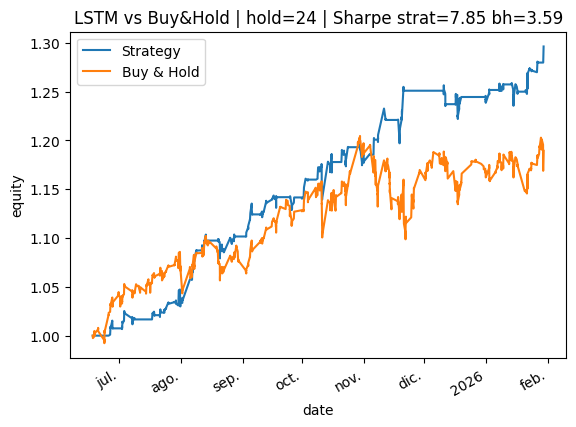

In [27]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_auc_score

# =========================
# FEATURES (con ts datetime)
# =========================
def make_features(df, include_time=True, include_volume=True):
    d = df.copy()

    # --- timestamp usable ---
    if isinstance(d.index, pd.DatetimeIndex):
        d["ts"] = d.index
    else:
        ts = None
        for c in ["datetime", "timestamp", "date", "time", "ts"]:
            if c in d.columns:
                ts = pd.to_datetime(d[c], errors="coerce", utc=True)
                break
        d["ts"] = ts

    # close numérico y positivo
    d["close"] = pd.to_numeric(d["close"], errors="coerce")
    d = d.dropna(subset=["close", "y"]).copy()
    d = d[d["close"] > 0].copy()

    # base
    d["logret1"] = np.log(d["close"]).diff()
    d["ret1"]    = d["close"].pct_change()

    # momentum multi-horizonte
    for l in [2, 3, 6, 12, 24, 48, 96]:
        d[f"logret_{l}"] = np.log(d["close"] / d["close"].shift(l))

    # vol multi-ventana
    for w in [5, 10, 20, 78, 156]:
        d[f"sigma_{w}"] = d["logret1"].rolling(w).std()

    d["zret_20"] = d["logret1"] / (d["sigma_20"] + 1e-8)
    d["zret_78"] = d["logret1"] / (d["sigma_78"] + 1e-8)

    # trend distancias
    for w in [20, 78]:
        ma = d["close"].rolling(w).mean()
        d[f"dist_ma_{w}"] = d["close"] / (ma + 1e-12) - 1
        ema = d["close"].ewm(span=w, adjust=False).mean()
        d[f"dist_ema_{w}"] = d["close"] / (ema + 1e-12) - 1

    # posición en rango
    for w in [20, 78]:
        lo = d["close"].rolling(w).min()
        hi = d["close"].rolling(w).max()
        d[f"pos_{w}"] = (d["close"] - lo) / (hi - lo + 1e-8)

    # RSI + MACD
    dd = d["close"].diff()
    up = dd.clip(lower=0)
    dn = (-dd).clip(lower=0)
    rs = up.rolling(14).mean() / (dn.rolling(14).mean() + 1e-12)
    d["rsi"] = 100 - 100/(1+rs)

    ema12 = d["close"].ewm(span=12, adjust=False).mean()
    ema26 = d["close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    d["macd_hist_pct"] = (macd - sig) / (d["close"] + 1e-12)

    feat_cols = (
        ["ret1","logret1"]
        + [f"logret_{l}" for l in [2,3,6,12,24,48,96]]
        + [f"sigma_{w}" for w in [5,10,20,78,156]]
        + ["zret_20","zret_78"]
        + [f"dist_ma_{w}" for w in [20,78]]
        + [f"dist_ema_{w}" for w in [20,78]]
        + [f"pos_{w}" for w in [20,78]]
        + ["rsi","macd_hist_pct"]
    )

    # time-of-day/day-of-week (si hay ts válida)
    if include_time and d["ts"].notna().any():
        ts = pd.to_datetime(d["ts"], errors="coerce", utc=True)
        minutes = ts.dt.hour * 60 + ts.dt.minute
        d["tod_sin"] = np.sin(2*np.pi*minutes/1440)
        d["tod_cos"] = np.cos(2*np.pi*minutes/1440)
        dow = ts.dt.dayofweek
        d["dow_sin"] = np.sin(2*np.pi*dow/7)
        d["dow_cos"] = np.cos(2*np.pi*dow/7)
        d[["tod_sin","tod_cos","dow_sin","dow_cos"]] = d[["tod_sin","tod_cos","dow_sin","dow_cos"]].fillna(0.0)
        feat_cols += ["tod_sin","tod_cos","dow_sin","dow_cos"]

    # volumen (si existe)
    if include_volume and ("volume" in d.columns):
        v = pd.to_numeric(d["volume"], errors="coerce").ffill()
        d["logvol"] = np.log(v.fillna(0.0) + 1.0)
        d["vol_z20"] = (d["logvol"] - d["logvol"].rolling(20).mean()) / (d["logvol"].rolling(20).std() + 1e-8)
        d[["logvol","vol_z20"]] = d[["logvol","vol_z20"]].fillna(0.0)
        feat_cols += ["logvol","vol_z20"]

    d = d.dropna(subset=feat_cols + ["y"]).copy()
    print(f"[make_features] rows after dropna: {len(d)} | n_features: {len(feat_cols)}")
    return d, feat_cols


# =========================
# Secuencias
# =========================
def build_sequences_with_index(d, feat_cols, L=64):
    if len(d) < L + 10:
        raise ValueError(f"No hay datos suficientes tras features: len(d)={len(d)}. Prueba L=32.")
    X = d[feat_cols].to_numpy(np.float32)
    y = d["y"].to_numpy(np.int64)
    idx = np.arange(L-1, len(d))
    Xs = np.stack([X[t-L+1:t+1] for t in idx])
    ys = y[idx]
    return Xs, ys, idx


# =========================
# Modelo
# =========================
class LockedDropout(nn.Module):
    def __init__(self, p=0.05):
        super().__init__()
        self.p = float(p)
    def forward(self, x):
        if (not self.training) or self.p <= 0.0:
            return x
        if x.dim() == 3:
            B, L, F = x.shape
            mask = x.new_empty(B, 1, F).bernoulli_(1 - self.p).div_(1 - self.p)
            return x * mask
        return nn.functional.dropout(x, p=self.p, training=True)

class TinyLSTM(nn.Module):
    def __init__(self, nfeat, hidden=64, p_in=0.05, p_h=0.05):
        super().__init__()
        self.drop_in = LockedDropout(p_in) if p_in > 0 else nn.Identity()
        self.lstm = nn.LSTM(input_size=nfeat, hidden_size=hidden, num_layers=1, batch_first=True)
        self.drop_h = LockedDropout(p_h) if p_h > 0 else nn.Identity()
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.drop_in(x)
        _, (hn, _) = self.lstm(x)
        h = self.drop_h(hn[-1])
        return self.head(h)

def best_threshold_balacc(p, y, tie_break=True):
    ths = np.linspace(0.05, 0.95, 181)
    ba = np.array([balanced_accuracy_score(y, (p > t).astype(int)) for t in ths])
    if tie_break:
        m = ba.max()
        idxs = np.where(np.isclose(ba, m, atol=1e-4))[0]
        rates = np.array([(p > ths[i]).mean() for i in idxs])
        i_best = idxs[np.argmin(np.abs(rates - y.mean()))]
        tbest = float(ths[i_best])
    else:
        tbest = float(ths[int(ba.argmax())])
    return float(ba.max()), tbest


# =========================
# Train + predict
# =========================
def train_predict(df, L=64, hidden=64, epochs=20, lr=1e-3, batch_size=256,
                  p_in=0.05, p_h=0.05, weight_decay=1e-4, seed=0,
                  early_stop=True, patience=3):
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    d, feat_cols = make_features(df, include_time=True, include_volume=True)
    Xs, ys, idx = build_sequences_with_index(d, feat_cols, L=L)

    n = len(ys)
    i1 = int(0.70*n)
    i2 = int(0.85*n)

    Xtr, ytr = Xs[:i1], ys[:i1]
    Xva, yva = Xs[i1:i2], ys[i1:i2]
    Xte, yte = Xs[i2:], ys[i2:]
    idx_te = idx[i2:]

    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-8
    Xtr = (Xtr - mu) / sd
    Xva = (Xva - mu) / sd
    Xte = (Xte - mu) / sd

    Xtr_t = torch.tensor(Xtr, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).view(-1, 1)
    Xva_t = torch.tensor(Xva, device=device)
    Xte_t = torch.tensor(Xte, device=device)

    model = TinyLSTM(nfeat=Xtr.shape[-1], hidden=hidden, p_in=p_in, p_h=p_h).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size,
        shuffle=True
    )

    best_state, best_val, bad = None, -1e9, 0

    for _ in range(epochs):
        model.train()
        for xb, yb in dl:
            loss = loss_fn(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        if early_stop:
            model.eval()
            with torch.no_grad():
                p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
            bal_val, _ = best_threshold_balacc(p_va, yva, tie_break=True)
            if bal_val > best_val + 1e-6:
                best_val = bal_val
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    with torch.no_grad():
        p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
        p_te = torch.sigmoid(model(Xte_t)).detach().cpu().numpy().ravel()

    bal_val, tbest = best_threshold_balacc(p_va, yva, tie_break=True)
    pred_te = (p_te > tbest).astype(int)

    out = {
        "L": L, "hidden": hidden, "tbest": tbest,
        "AUC_val": float(roc_auc_score(yva, p_va)),
        "AUC_test": float(roc_auc_score(yte, p_te)),
        "bal_val": float(bal_val),
        "bal_test": float(balanced_accuracy_score(yte, pred_te)),
        "pred_pos_rate": float(pred_te.mean()),
        "rows_used": int(len(d)),
        "n_features": int(len(feat_cols)),
    }
    print(out)
    print("Confusion matrix (test):\n", confusion_matrix(yte, pred_te))
    return d, idx_te, yte, p_te, tbest, out


# =========================
# Backtest + Sharpe
# =========================
def backtest_holdH(d, idx_te, p_te, tbest, hold_bars=24, fee_bps=0.0,
                   allow_short=False, entry_margin=0.0,
                   bars_per_day=78, days_per_year=252):

    te = d.iloc[idx_te].copy()
    te["p"] = p_te

    close = te["close"].to_numpy(dtype=float)
    ret = np.zeros_like(close, dtype=np.float64)
    ret[1:] = close[1:] / close[:-1] - 1.0

    pos = np.zeros(len(te), dtype=np.int8)
    entries = []

    long_thr = tbest + entry_margin
    short_thr = (1.0 - tbest) - entry_margin

    i = 0
    while i < len(te) - 1:
        direction = 0
        p = float(te["p"].iloc[i])
        if p > long_thr:
            direction = 1
        elif allow_short and p < short_thr:
            direction = -1

        if direction != 0:
            j = min(i + hold_bars, len(te))
            pos[i:j] = direction
            entries.append(i)
            i = j
        else:
            i += 1

    strat_ret = np.zeros_like(ret)
    strat_ret[1:] = pos[:-1] * ret[1:]

    if fee_bps and fee_bps > 0:
        cost = fee_bps / 10000.0
        changes = np.diff(pos, prepend=0)
        strat_ret[changes != 0] -= cost

    strat_eq = np.cumprod(1.0 + strat_ret)
    bh_eq = np.cumprod(1.0 + ret)

    def max_dd(eq):
        peak = np.maximum.accumulate(eq)
        return float((eq/peak - 1.0).min())

    def sharpe(r, ann_factor):
        r = np.asarray(r, dtype=float)
        r = r[np.isfinite(r)]
        if r.size < 2:
            return np.nan
        mu = r.mean()
        sd = r.std(ddof=1)
        if sd <= 1e-12:
            return np.nan
        return float((mu / sd) * np.sqrt(ann_factor))

    ann = bars_per_day * days_per_year

    stats = {
        "n_trades": int(len(entries)),
        "time_in_mkt": float((pos != 0).mean()),
        "strat_total_ret": float(strat_eq[-1] - 1.0),
        "bh_total_ret": float(bh_eq[-1] - 1.0),
        "strat_max_dd": max_dd(strat_eq),
        "bh_max_dd": max_dd(bh_eq),
        "strat_sharpe": sharpe(strat_ret[1:], ann),
        "bh_sharpe": sharpe(ret[1:], ann),
    }

    te["pos"] = pos
    te["ret"] = ret
    te["strat_eq"] = strat_eq
    te["bh_eq"] = bh_eq
    return te, stats

def plot_equity(te, title="Strategy vs Buy&Hold"):
    x = te["ts"] if "ts" in te.columns else te.index
    x = pd.to_datetime(x, errors="coerce", utc=True)

    plt.figure()
    if x.notna().all():
        plt.plot(x, te["strat_eq"], label="Strategy")
        plt.plot(x, te["bh_eq"], label="Buy & Hold")
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
        plt.gcf().autofmt_xdate()
    else:
        plt.plot(te["strat_eq"], label="Strategy")
        plt.plot(te["bh_eq"], label="Buy & Hold")

    plt.title(title)
    plt.xlabel("date")
    plt.ylabel("equity")
    plt.legend()
    plt.show()


# =========================
# RUN
# =========================
hold_bars = int(globals().get("H", 24))

d, idx_te, yte, p_te, tbest, out = train_predict(df, L=64, hidden=64, epochs=20, seed=0)

te, stats = backtest_holdH(
    d, idx_te, p_te, tbest,
    hold_bars=hold_bars,
    fee_bps=0.0,
    allow_short=False,
    entry_margin=0.0,
    bars_per_day=78,   # si es 5m RTH; si es 24h -> 288
    days_per_year=252
)

print("\nBACKTEST STATS:")
for k,v in stats.items():
    print(f"{k:>16}: {v}")

print("\nTEST window:", te["ts"].min(), "->", te["ts"].max())

plot_equity(te, title=f"LSTM vs Buy&Hold | hold={hold_bars} | Sharpe strat={stats['strat_sharpe']:.2f} bh={stats['bh_sharpe']:.2f}")

tbest_ens: 0.57 | bal_val_ens: 0.5588275706910791

ENSEMBLE BACKTEST (calibrado en VALID): {'n_trades': 62, 'time_in_mkt': 0.5252560932532674, 'strat_total_ret': 0.23947373932479588, 'bh_total_ret': 0.18944662836408366, 'strat_max_dd': -0.06065595343307939, 'bh_max_dd': -0.08791163965546944, 'strat_sharpe': 5.822077323655929, 'bh_sharpe': 3.5865415937840113}


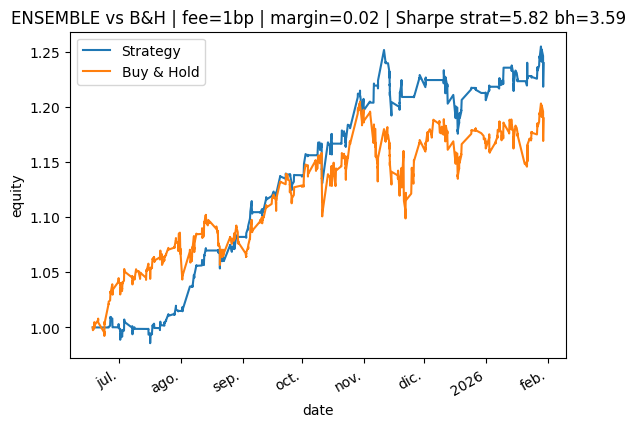

In [30]:
import numpy as np
import io, contextlib

def train_predict_full(df, L=64, hidden=64, epochs=20, lr=1e-3, batch_size=256,
                       p_in=0.05, p_h=0.05, weight_decay=1e-4, seed=0,
                       early_stop=True, patience=3):
    # misma lógica que tu train_predict, pero devuelve también VALID
    torch.manual_seed(seed); np.random.seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    d, feat_cols = make_features(df, include_time=True, include_volume=True)
    Xs, ys, idx = build_sequences_with_index(d, feat_cols, L=L)

    n = len(ys)
    i1 = int(0.70*n)
    i2 = int(0.85*n)

    Xtr, ytr = Xs[:i1], ys[:i1]
    Xva, yva = Xs[i1:i2], ys[i1:i2]
    Xte, yte = Xs[i2:], ys[i2:]
    idx_te = idx[i2:]

    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(0) + 1e-8
    Xtr = (Xtr - mu) / sd
    Xva = (Xva - mu) / sd
    Xte = (Xte - mu) / sd

    Xtr_t = torch.tensor(Xtr, device=device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device).view(-1, 1)
    Xva_t = torch.tensor(Xva, device=device)
    Xte_t = torch.tensor(Xte, device=device)

    model = TinyLSTM(nfeat=Xtr.shape[-1], hidden=hidden, p_in=p_in, p_h=p_h).to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size,
        shuffle=True
    )

    best_state, best_val, bad = None, -1e9, 0

    for _ in range(epochs):
        model.train()
        for xb, yb in dl:
            loss = loss_fn(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        if early_stop:
            model.eval()
            with torch.no_grad():
                p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
            bal_val, _ = best_threshold_balacc(p_va, yva, tie_break=True)
            if bal_val > best_val + 1e-6:
                best_val = bal_val
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    model.eval()
    with torch.no_grad():
        p_va = torch.sigmoid(model(Xva_t)).detach().cpu().numpy().ravel()
        p_te = torch.sigmoid(model(Xte_t)).detach().cpu().numpy().ravel()

    return d, idx_te, yva, yte, p_va, p_te

# ========= ENSEMBLE =========
seeds = list(range(10))

p_va_list, p_te_list = [], []
for s in seeds:
    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        d, idx_te, yva, yte, p_va, p_te = train_predict_full(df, L=64, hidden=64, epochs=20, seed=s)
    p_va_list.append(p_va)
    p_te_list.append(p_te)

p_va_ens = np.mean(p_va_list, axis=0)
p_te_ens = np.mean(p_te_list, axis=0)

bal_val_ens, tbest_ens = best_threshold_balacc(p_va_ens, yva, tie_break=True)
print("tbest_ens:", tbest_ens, "| bal_val_ens:", bal_val_ens)

te_ens, st_ens = backtest_holdH(
    d, idx_te, p_te_ens, tbest_ens,
    hold_bars=hold_bars,
    fee_bps=1.0,
    allow_short=False,
    entry_margin=0.02,
    bars_per_day=78,
    days_per_year=252
)

print("\nENSEMBLE BACKTEST (calibrado en VALID):", st_ens)
plot_equity(te_ens, title=f"ENSEMBLE vs B&H | fee=1bp | margin=0.02 | Sharpe strat={st_ens['strat_sharpe']:.2f} bh={st_ens['bh_sharpe']:.2f}")